In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
from openai import OpenAI
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.environ.get('API_KEY')

client = OpenAI(api_key=api_key)

from src.utils import pairwise_cosine_similarity
from sentence_transformers import SentenceTransformer
# load embedding model
embedding_model_path = "BAAI/bge-large-en-v1.5"
embedding_model = SentenceTransformer(embedding_model_path)

import seaborn as sns

In [2]:
def get_age(abstract):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": [
                    {
                    "type": "text",
                    "text": "You are a biomedical natural language processing assistant. Given the abstract of a clinical trial study, your task is to extract or infer the average age (in years) of the study population.\n\nYour output must be in the following JSON format:\n{\n  \"age\": 54.3  // numerical value only\n}\n\nGuidelines:\n1. If the study mentions the **mean or average age**, extract and return that value.\n2. If the study mentions an **age range** (e.g., \"30 to 50 years\"), compute the average (e.g., (30+50)/2 = 40.0) and return that value.\n3. If no explicit age value is mentioned, infer the most likely average age based on population group terms in the text, using this mapping:\n\n- \"Child, Preschool\": 2–5 years → 3.5\n- \"Child\": 6–12 years → 9\n- \"Adolescent\": 13–18 years → 15.5\n- \"Adult\": 19–44 years → 31.5\n- \"Middle Aged\": 45–64 years → 54.5\n- \"Aged\": 65+ years → 75\n- \"Aged, 80 and over\": 80+ years → 85\n- \"Octogenarians\": 80–89 years → 84.5\n- \"Nonagenarians\": 90–99 years → 94.5\n- \"Centenarians\": 100+ years → 100\n\nChoose the most appropriate inferred value if only a population label is present.\n\nOnly include the JSON output. Do not explain or add commentary."
                    }
                ]
            },
            {
                "role": "user",
                "content": [
                    {
                    "type": "text",
                    "text": "Now process the following abstract:\n{}".format(abstract)
                    }
                ]
            }
        ],
        response_format={
            "type": "json_object"
        },
        temperature=1,
        max_completion_tokens=2048,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        store=False
    )

    return response.choices[0].message.content

# Aged

In [3]:
aged_df = pd.read_csv("../data/pubmed_rct/cav_files/penalty=1.2/all_aged_results.tsv", sep="\t")

In [4]:
# alpha = 0 (original abstract)
abstracts = aged_df["abstract"].to_list()
age_results = []
for abstract in abstracts:
    j_output = get_age(abstract)
    age_results.append(json.loads(j_output).get("age"))

aged_df["age_{}".format(0)] = age_results

In [5]:
alpha_list = [-0.0625, -0.125, -0.25, -0.5, -1, -2, -4, -8]
pbar = tqdm(total=len(aged_df)*len(alpha_list))

for alpha in alpha_list:

    abstracts = aged_df["abstract_{}".format(alpha)].to_list()
    
    age_results = []
    for abstract in abstracts:
        j_output = get_age(abstract)
        age_results.append(json.loads(j_output).get("age"))
        pbar.update(1)
    
    aged_df["age_{}".format(alpha)] = age_results

pbar.close()

100%|██████████| 400/400 [04:36<00:00,  1.45it/s]


In [7]:
aged_df.to_csv("../data/pubmed_rct/cav_files/penalty=1.2/all_aged_results.tsv", sep="\t", index=False)

<Axes: >

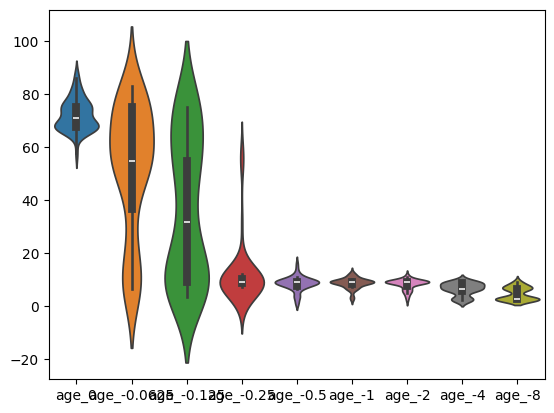

In [6]:
alpha_list = [0, -0.0625, -0.125, -0.25, -0.5, -1, -2, -4, -8]
sns.violinplot(data=aged_df[[f"age_{alpha}" for alpha in alpha_list]])

In [8]:
aged_reference_embs = embedding_model.encode(aged_df["abstract"].to_list())
alpha_list = [-0.0625, -0.125, -0.25, -0.5, -1, -2, -4, -8]
for alpha in alpha_list:
    abstracts = aged_df["abstract_{}".format(alpha)].to_list()
    test_embs = embedding_model.encode(abstracts)
    cosine_list = pairwise_cosine_similarity(aged_reference_embs, test_embs)
    print(alpha, np.mean(cosine_list), np.std(cosine_list))

-0.0625 0.8586643671989441 0.03643632522387514
-0.125 0.850201450586319 0.0392196965242018
-0.25 0.8245991241931915 0.03954390663445721
-0.5 0.8005189418792724 0.04677872890149724
-1 0.7444440162181855 0.05241363078776
-2 0.6555292499065399 0.041743344763493395
-4 0.5972302788496018 0.04566575158489032
-8 0.5744623053073883 0.04102953282685315


# Child

In [9]:
child_df = pd.read_csv("../data/pubmed_rct/cav_files/penalty=1.2/all_child_results.tsv", sep="\t")

In [10]:
# alpha = 0 
abstracts = child_df["abstract"].to_list()
age_results = []
for abstract in abstracts:
    j_output = get_age(abstract)
    age_results.append(json.loads(j_output).get("age"))

child_df["age_{}".format(0)] = age_results

In [11]:
alpha_list = [0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8]
pbar = tqdm(total=len(child_df)*len(alpha_list))

for alpha in alpha_list:

    abstracts = child_df["abstract_{}".format(alpha)].to_list()
    
    age_results = []
    for abstract in abstracts:
        j_output = get_age(abstract)
        age_results.append(json.loads(j_output).get("age"))
        pbar.update(1)
    
    child_df["age_{}".format(alpha)] = age_results

pbar.close()

100%|██████████| 400/400 [04:33<00:00,  1.46it/s]


In [12]:
child_df.to_csv("../data/pubmed_rct/cav_files/penalty=1.2/all_child_results.tsv", sep="\t", index=False)

<Axes: >

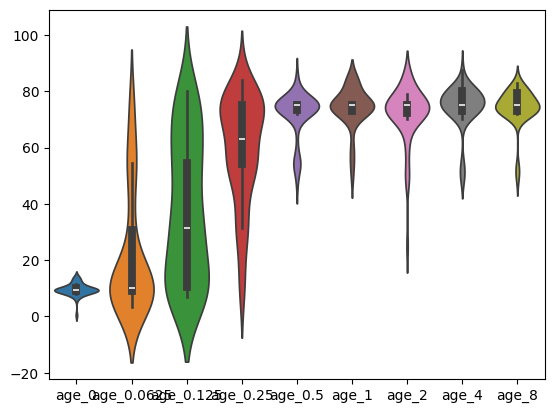

In [13]:
alpha_list = [0, 0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8]
sns.violinplot(data=child_df[[f"age_{alpha}" for alpha in alpha_list]])

In [14]:
child_reference_embs = embedding_model.encode(child_df["abstract"].to_list())
alpha_list = [0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8]
for alpha in alpha_list:
    abstracts = child_df["abstract_{}".format(alpha)].to_list()
    test_embs = embedding_model.encode(abstracts)
    cosine_list = pairwise_cosine_similarity(child_reference_embs, test_embs)
    print(alpha, np.mean(cosine_list), np.std(cosine_list))

0.0625 0.8586657989025116 0.03685372234610389
0.125 0.8532673180103302 0.03942013185790271
0.25 0.8329455482959748 0.038642229812110906
0.5 0.8063903033733368 0.039073529732417796
1 0.76753244638443 0.04647876538567761
2 0.7052963817119599 0.04815293063294672
4 0.6507126104831695 0.05772246937198719
8 0.6278104341030121 0.046449552912999494
